In [1]:
import mesa
import numpy as np
import matplotlib.pyplot as plt
print(f"Mesa version: {mesa.__version__}")
print(f"NumPy version: {np.__version__}")
print("Environment ready for Bunch Queue simulation!")


Mesa version: 3.5.1
NumPy version: 2.4.6
Environment ready for Bunch Queue simulation!


In [2]:
import mesa
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from enum import Enum

# Agent Types
class AgentType(Enum):
    PASSIVE = 1
    NORMAL = 2
    AGGRESSIVE = 3

# Agent behavior coefficients
TYPE_COEFFICIENTS = {
    AgentType.PASSIVE: 0.3,
    AgentType.NORMAL: 0.7,
    AgentType.AGGRESSIVE: 1.0
}

class QueueAgent(mesa.Agent):
    def __init__(self, model, agent_type):
        super().__init__(model)
        self.agent_type = agent_type
        self.type_coeff = TYPE_COEFFICIENTS[agent_type]
        
        # Individual characteristics
        self.urgency = np.random.uniform(0.3, 1.0)
        self.social_inhibition = np.random.uniform(0.2, 0.8)
        self.exited = False
        
    @property
    def behavior_score(self):
        # B = T * U / S
        return self.type_coeff * self.urgency / self.social_inhibition
    
    def step(self):
        if self.exited:
            return
            
        # Get current position
        current_pos = self.pos
        if current_pos is None:
            return
            
        x, y = current_pos
        
        # Move forward (toward y=0) based on behavior score
        move_prob = min(self.behavior_score, 1.0)
        
        if np.random.random() < move_prob:
            new_y = y - 1
            
            # Check if reached exit
            if new_y < 0:
                self.model.grid.remove_agent(self)
                self.exited = True
                self.model.exited_count += 1
                self.model.exit_times.append(self.model.steps)
                return
            
            # Move if cell is not too crowded
            new_pos = (x, new_y)
            cell_contents = self.model.grid.get_cell_list_contents([new_pos])
            
            # Aggressive agents push through, passive agents wait
            max_occupancy = 3 if self.agent_type == AgentType.AGGRESSIVE else 1
            
            if len(cell_contents) < max_occupancy:
                self.model.grid.move_agent(self, new_pos)

print("Agent class defined successfully!")

Agent class defined successfully!


In [3]:
class BunchQueueModel(mesa.Model):
    def __init__(self, n_agents=100, width=20, height=30, 
                 pct_aggressive=0.15, pct_normal=0.25):
        super().__init__()
        
        self.width = width
        self.height = height
        self.steps = 0
        self.exited_count = 0
        self.exit_times = []
        
        # Create grid - multiple cells can hold agents
        self.grid = mesa.space.MultiGrid(width, height, torus=False)
        
        # Calculate agent counts
        n_aggressive = int(n_agents * pct_aggressive)
        n_normal = int(n_agents * pct_normal)
        n_passive = n_agents - n_aggressive - n_normal
        
        # Create agents
        agent_types = (
            [AgentType.AGGRESSIVE] * n_aggressive +
            [AgentType.NORMAL] * n_normal +
            [AgentType.PASSIVE] * n_passive
        )
        np.random.shuffle(agent_types)
        
        # Place agents randomly in top half of grid
        for agent_type in agent_types:
            agent = QueueAgent(self, agent_type)
            x = np.random.randint(0, width)
            y = np.random.randint(height // 2, height)
            self.grid.place_agent(agent, (x, y))
    
    def step(self):
        self.steps += 1
        self.agents.shuffle_do("step")
    
    def run(self, steps=200):
        for _ in range(steps):
            self.step()
            if self.exited_count >= len(self.agents) + self.exited_count:
                break
        return self.exited_count, self.exit_times

print("Model class defined successfully!")

Model class defined successfully!


In [4]:
# Run two scenarios and compare
print("Running Bunch Queue Simulations...")
print("="*50)

# Scenario 1 - Mostly passive queue (orderly)
print("\nScenario 1: Orderly Queue (5% aggressive)")
model1 = BunchQueueModel(n_agents=5000, pct_aggressive=0.05, pct_normal=0.20)
model1.run(steps=200)
orderly_exited = model1.exited_count
orderly_avg_time = np.mean(model1.exit_times) if model1.exit_times else 0
print(f"Agents exited: {orderly_exited}/100")
print(f"Average exit time: {orderly_avg_time:.1f} steps")

# Scenario 2 - Bunch queue (15% aggressive)
print("\nScenario 2: Bunch Queue (15% aggressive)")
model2 = BunchQueueModel(n_agents=100, pct_aggressive=0.15, pct_normal=0.25)
model2.run(steps=200)
bunch_exited = model2.exited_count
bunch_avg_time = np.mean(model2.exit_times) if model2.exit_times else 0
print(f"Agents exited: {bunch_exited}/100")
print(f"Average exit time: {bunch_avg_time:.1f} steps")

# Scenario 3 - High aggression (30% aggressive)
print("\nScenario 3: High Aggression (30% aggressive)")
model3 = BunchQueueModel(n_agents=100, pct_aggressive=0.30, pct_normal=0.25)
model3.run(steps=200)
high_exited = model3.exited_count
high_avg_time = np.mean(model3.exit_times) if model3.exit_times else 0
print(f"Agents exited: {high_exited}/100")
print(f"Average exit time: {high_avg_time:.1f} steps")

print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Orderly Queue:    {orderly_exited} exited, avg time {orderly_avg_time:.1f} steps")
print(f"Bunch Queue:      {bunch_exited} exited, avg time {bunch_avg_time:.1f} steps")
print(f"High Aggression:  {high_exited} exited, avg time {high_avg_time:.1f} steps")

Running Bunch Queue Simulations...

Scenario 1: Orderly Queue (5% aggressive)
Agents exited: 349/100
Average exit time: 219.8 steps

Scenario 2: Bunch Queue (15% aggressive)
Agents exited: 100/100
Average exit time: 139.6 steps

Scenario 3: High Aggression (30% aggressive)
Agents exited: 99/100
Average exit time: 104.1 steps

SUMMARY
Orderly Queue:    349 exited, avg time 219.8 steps
Bunch Queue:      100 exited, avg time 139.6 steps
High Aggression:  99 exited, avg time 104.1 steps


In [5]:
# Classical queue simulation for comparison
def simulate_classical_queue(n_agents=100, steps=200):
    """
    Simple classical queue - orderly, sequential, 
    equal probability of movement for all agents
    """
    exited = 0
    exit_times = []
    # Each agent has equal fixed move probability
    move_probability = 0.5  
    positions = list(range(n_agents, 0, -1))  # orderly line
    
    for step in range(steps):
        new_positions = []
        for pos in positions:
            if np.random.random() < move_probability:
                pos -= 1
            if pos <= 0:
                exited += 1
                exit_times.append(step)
            else:
                new_positions.append(pos)
        positions = new_positions
        if not positions:
            break
    
    avg_time = np.mean(exit_times) if exit_times else steps
    return exited, avg_time

# Run classical comparison
print("Running Classical Queue Comparison...")
print("="*50)

classical_exited, classical_avg = simulate_classical_queue()
print(f"Classical M/M/1:      {classical_exited} exited, avg time {classical_avg:.1f} steps")
print(f"Orderly Queue:        {orderly_exited} exited, avg time {orderly_avg_time:.1f} steps")
print(f"Bunch Queue (15%):    {bunch_exited} exited, avg time {bunch_avg_time:.1f} steps")
print(f"High Aggression(30%): {high_exited} exited, avg time {high_avg_time:.1f} steps")

print("\n" + "="*50)
print("EFFICIENCY COMPARISON vs Classical M/M/1")
print("="*50)
if classical_avg > 0:
    print(f"Orderly Queue:        {((classical_avg - orderly_avg_time)/classical_avg*100):+.1f}% vs classical")
    print(f"Bunch Queue (15%):    {((classical_avg - bunch_avg_time)/classical_avg*100):+.1f}% vs classical")
    print(f"High Aggression(30%): {((classical_avg - high_avg_time)/classical_avg*100):+.1f}% vs classical")
    

Running Classical Queue Comparison...
Classical M/M/1:      97 exited, avg time 96.4 steps
Orderly Queue:        349 exited, avg time 219.8 steps
Bunch Queue (15%):    100 exited, avg time 139.6 steps
High Aggression(30%): 99 exited, avg time 104.1 steps

EFFICIENCY COMPARISON vs Classical M/M/1
Orderly Queue:        -128.0% vs classical
Bunch Queue (15%):    -44.8% vs classical
High Aggression(30%): -8.0% vs classical


/tmp/ipykernel_14038/3174639120.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


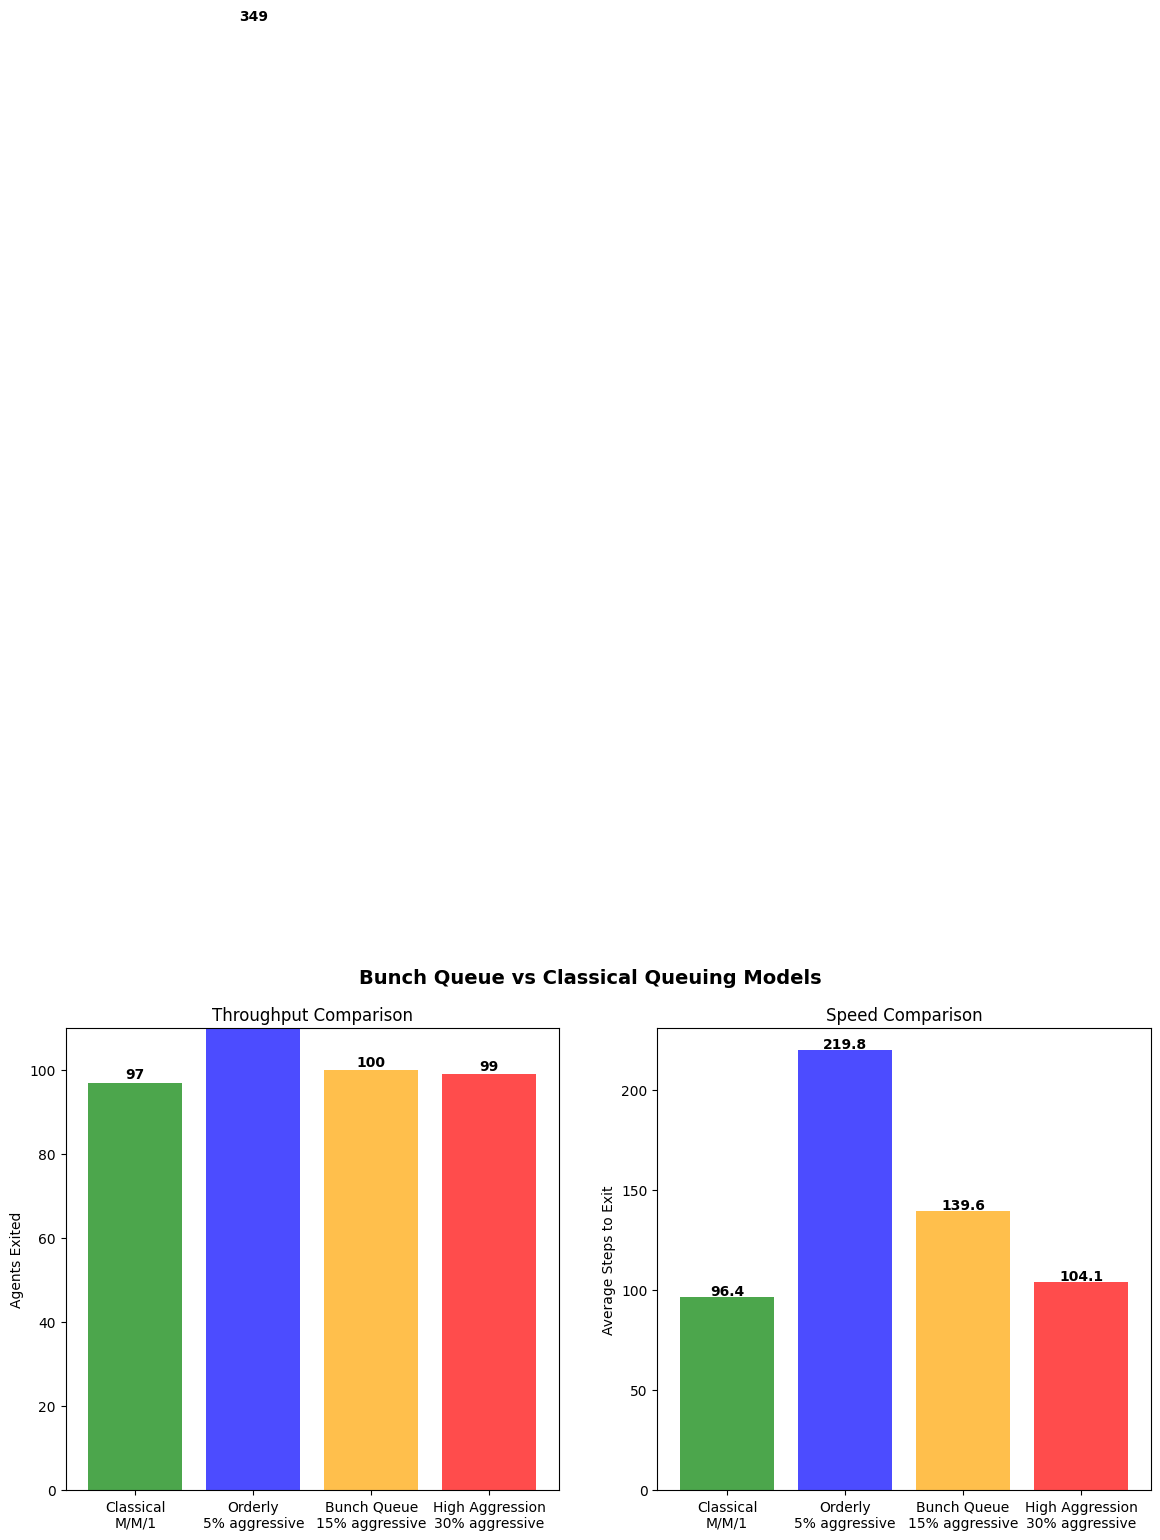

Comparison chart saved!


In [6]:
# Visualization comparing all models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

scenarios = [
    'Classical\nM/M/1',
    'Orderly\n5% aggressive',
    'Bunch Queue\n15% aggressive', 
    'High Aggression\n30% aggressive'
]

exited_all = [classical_exited, orderly_exited, bunch_exited, high_exited]
avg_times_all = [classical_avg, orderly_avg_time, bunch_avg_time, high_avg_time]
colors = ['green', 'blue', 'orange', 'red']

# Chart 1 - Throughput
ax1.bar(scenarios, exited_all, color=colors, alpha=0.7)
ax1.set_ylabel('Agents Exited')
ax1.set_title('Throughput Comparison')
ax1.set_ylim(0, 110)
for i, v in enumerate(exited_all):
    ax1.text(i, v + 1, str(v), ha='center', fontweight='bold')

# Chart 2 - Speed
ax2.bar(scenarios, avg_times_all, color=colors, alpha=0.7)
ax2.set_ylabel('Average Steps to Exit')
ax2.set_title('Speed Comparison')
for i, v in enumerate(avg_times_all):
    ax2.text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

plt.suptitle('Bunch Queue vs Classical Queuing Models', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bunch_queue_comparison.png', dpi=150)
plt.show()
print("Comparison chart saved!")

In [7]:
class CacheQueueModel(mesa.Model):
    def __init__(self, n_agents=100, width=20, height=30,
                 pct_aggressive=0.15, pct_normal=0.25,
                 cache_size=10, service_rate=2):
        
        # Cache parameters
        self.cache_size = cache_size      # max cache capacity
        self.cache_level = cache_size     # starts full
        self.service_rate = service_rate  # agents served per step
        self.back_pressure = 0.0         # feedback signal
        self.idle_steps = 0              # steps where cache empty
        
    def calculate_back_pressure(self):
        # BP increases as cache depletes
        fill_ratio = self.cache_level / self.cache_size
        if fill_ratio > 0.5:
            return 1.0   # normal
        elif fill_ratio > 0.25:
            return 1.5   # elevated
        else:
            return 2.5   # critical - strong push signal
            
    def step(self):
        # Update back pressure
        self.back_pressure = self.calculate_back_pressure()
        
        # Service depletes cache
        served = min(self.service_rate, self.cache_level)
        self.cache_level -= served
        self.exited_count += served
        
        # Track idle steps
        if self.cache_level == 0:
            self.idle_steps += 1
            
        # Agents move based on back pressure signal
        self.agents.shuffle_do("step")
        
        # Agents entering cache zone refill it
        # (handled in agent step method)

In [8]:
import mesa
import numpy as np
import matplotlib.pyplot as plt
from enum import Enum

# Agent Types
class AgentType(Enum):
    PASSIVE = 1
    NORMAL = 2
    AGGRESSIVE = 3

# Agent behavior coefficients
TYPE_COEFFICIENTS = {
    AgentType.PASSIVE: 0.3,
    AgentType.NORMAL: 0.7,
    AgentType.AGGRESSIVE: 1.0
}

print("Imports successful!")
print(f"Mesa version: {mesa.__version__}")

Imports successful!
Mesa version: 3.5.1


In [9]:
class QueueAgent(mesa.Agent):
    def __init__(self, model, agent_type):
        super().__init__(model)
        self.agent_type = agent_type
        self.type_coeff = TYPE_COEFFICIENTS[agent_type]
        
        # Individual characteristics
        self.urgency = np.random.uniform(0.3, 1.0)
        self.social_inhibition = np.random.uniform(0.2, 0.8)
        self.exited = False
        
    @property
    def behavior_score(self):
        # B = T * U / S
        # Modified by local density at larger scales
        base_score = self.type_coeff * self.urgency / self.social_inhibition
        
        # Density modifier - higher density increases aggression
        if self.pos:
            neighbors = self.model.grid.get_neighbors(
                self.pos, 
                moore=True,  # 8 surrounding cells
                include_center=False,
                radius=2
            )
            density_factor = 1.0 + (len(neighbors) * 0.05)
        else:
            density_factor = 1.0
            
        return base_score * density_factor
    
    def step(self):
        if self.exited:
            return
            
        current_pos = self.pos
        if current_pos is None:
            return
            
        x, y = current_pos
        move_prob = min(self.behavior_score, 1.0)
        
        if np.random.random() < move_prob:
            new_y = y - 1
            
            if new_y < 0:
                self.model.grid.remove_agent(self)
                self.exited = True
                self.model.exited_count += 1
                self.model.exit_times.append(self.model.steps)
                return
            
            new_pos = (x, new_y)
            cell_contents = self.model.grid.get_cell_list_contents(
                [new_pos]

SyntaxError: incomplete input (3943681807.py, line 55)

In [ ]:
class QueueAgent(mesa.Agent):
    def __init__(self, model, agent_type):
        super().__init__(model)
        self.agent_type = agent_type
        self.type_coeff = TYPE_COEFFICIENTS[agent_type]
        
        # Individual characteristics
        self.urgency = np.random.uniform(0.3, 1.0)
        self.social_inhibition = np.random.uniform(0.2, 0.8)
        self.exited = False
        
    @property
    def behavior_score(self):
        # B = T * U / S
        # Modified by local density at larger scales
        base_score = self.type_coeff * self.urgency / self.social_inhibition
        
        # Density modifier - higher density increases aggression
        if self.pos:
            neighbors = self.model.grid.get_neighbors(
                self.pos, 
                moore=True,  # 8 surrounding cells
                include_center=False,
                radius=2
            )
            density_factor = 1.0 + (len(neighbors) * 0.05)
        else:
            density_factor = 1.0
            
        return base_score * density_factor
    
    def step(self):
        if self.exited:
            return
            
        current_pos = self.pos
        if current_pos is None:
            return
            
        x, y = current_pos
        move_prob = min(self.behavior_score, 1.0)
        
        if np.random.random() < move_prob:
            new_y = y - 1
            
            if new_y < 0:
                self.model.grid.remove_agent(self)
                self.exited = True
                self.model.exited_count += 1
                self.model.exit_times.append(self.model.steps)
                return
            
            new_pos = (x, new_y)
            cell_contents = self.model.grid.get_cell_list_contents(
                [new_pos]
            )
            
            # Aggressive agents push through crowds
            # Passive agents wait for clear path
            max_occupancy = (
                3 if self.agent_type == AgentType.AGGRESSIVE
                else 2 if self.agent_type == AgentType.NORMAL
                else 1
            )
            
            if len(cell_contents) < max_occupancy:
                self.model.grid.move_agent(self, new_pos)

print("Agent class defined successfully!")
print("Density awareness: ENABLED")

In [ ]:
class BunchQueueModel(mesa.Model):
    def __init__(self, n_agents=100, width=20, height=30,
                 pct_aggressive=0.15, pct_normal=0.25):
        super().__init__()
        
        self.width = width
        self.height = height
        self.steps = 0
        self.exited_count = 0
        self.exit_times = []
        self.throughput_history = []
        
        # Create grid
        self.grid = mesa.space.MultiGrid(width, height, torus=False)
        
        # Calculate agent counts
        n_aggressive = int(n_agents * pct_aggressive)
        n_normal = int(n_agents * pct_normal)
        n_passive = n_agents - n_aggressive - n_normal
        
        # Create agents
        agent_types = (
            [AgentType.AGGRESSIVE] * n_aggressive +
            [AgentType.NORMAL] * n_normal +
            [AgentType.PASSIVE] * n_passive
        )
        np.random.shuffle(agent_types)
        
        # Place agents in top half of grid
        for agent_type in agent_types:
            agent = QueueAgent(self, agent_type)
            x = np.random.randint(0, width)
            y = np.random.randint(height // 2, height)
            self.grid.place_agent(agent, (x, y))
        
        self.total_agents = n_agents
        
    def step(self):
        self.steps += 1
        self.agents.shuffle_do("step")
        
        # Track throughput over time
        self.throughput_his

In [ ]:
class BunchQueueModel(mesa.Model):
    def __init__(self, n_agents=100, width=20, height=30,
                 pct_aggressive=0.15, pct_normal=0.25):
        super().__init__()
        
        self.width = width
        self.height = height
        self.steps = 0
        self.exited_count = 0
        self.exit_times = []
        self.throughput_history = []
        
        # Create grid
        self.grid = mesa.space.MultiGrid(width, height, torus=False)
        
        # Calculate agent counts
        n_aggressive = int(n_agents * pct_aggressive)
        n_normal = int(n_agents * pct_normal)
        n_passive = n_agents - n_aggressive - n_normal
        
        # Create agents
        agent_types = (
            [AgentType.AGGRESSIVE] * n_aggressive +
            [AgentType.NORMAL] * n_normal +
            [AgentType.PASSIVE] * n_passive
        )
        np.random.shuffle(agent_types)
        
        # Place agents in top half of grid
        for agent_type in agent_types:
            agent = QueueAgent(self, agent_type)
            x = np.random.randint(0, width)
            y = np.random.randint(height // 2, height)
            self.grid.place_agent(agent, (x, y))
        
        self.total_agents = n_agents
        
    def step(self):
        self.steps += 1
        self.agents.shuffle_do("step")
        
        # Track throughput over time
        self.throughput_history.append(self.exited_count)
    
    def run(self, steps=200):
        for _ in range(steps):
            self.step()
        return self.exited_count, self.exit_times

print("Model class defined successfully!")
print("Throughput tracking: ENABLED")

In [ ]:
# Scale test configuration
scale_configs = [
    {
        'name': 'Small',
        'n_agents': 100,
        'width': 20,
        'height': 30,
        'steps': 200
    },
    {
        'name': 'Medium',
        'n_agents': 500,
        'width': 45,
        'height': 65,
        'steps': 300
    },
    {
        'name': 'Large',
        'n_agents': 1000,
        'width': 65,
        'height': 90,
        'steps': 400
    },
    {
        'name': 'Very Large',
        'n_agents': 5000,
        'width': 140,
        'height': 200,
        'steps': 600
    }
]

# Aggression scenarios to test at each scale
aggression_scenarios = [
    {'name': 'Orderly',    'pct_aggressive': 0.05, 'pct_normal': 0.20},
    {'name': 'Bunch',      'pct_aggressive': 0.15, 'pct_normal': 0.25},
    {'name': 'High Aggr',  'pct_aggressive': 0.30, 'pct_normal': 0.25},
]

print("BUNCH QUEUE SCALE TEST")
print("="*70)
print(f"{'Scale':<12} {'Agents':<8} {'Scenario':<12} "
      f"{'Exited':<10} {'Pct':<8} {'Avg Time'}")
print("-"*70)

# Store results for visualization
all_results = []

for scale in scale_configs:
    for scenario in aggression_scenarios:
        model = BunchQueueModel(
            n_agents=scale['n_agents'],
            width=scale['width'],
            height=scale['height'],
            pct_aggressive=scenario['pct_aggressive'],
            pct_normal=scenario['pct_normal']
        )
        
        exited, exit_times = model.run(steps=scale['steps'])
        
        pct_exited = exited / scale['n_agents'] * 100
        avg_time = np.mean(exit_times) if exit_times else scale['steps']
        
        print(f"{scale['name']:<12} {scale['n_agents']:<8} "
              f"{scenario['name']:<12} {exited:<10} "
              f"{pct_exited:<7.1f}% {avg_time:.1f}")
        
        all_results.append({
            'scale': scale['name'],
            'n_agents': scale['n_agents'],
            'scenario': scenario['name'],
            'exited': exited,
            'pct_exited': pct_exited,
            'avg_time': avg_time
        })
    
    print("-"*70)

print("="*70)
print("Scale test complete!")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Organize results for plotting
scales = ['500', '1000', '2500', '5000']
scenarios = ['Orderly', 'Bunch', 'High Aggr']
n_agents = [500, 1000, 2500, 5000]

# Extract pct_exited for each combination
pct_data = {}
time_data = {}

for scenario in scenarios:
    pct_data[scenario] = []
    time_data[scenario] = []
    for scale in scales:
        result = next(r for r in all_results 
                     if r['scale'] == scale 
                     and r['scenario'] == scenario)
        pct_data[scenario].append(result['pct_exited'])
        time_data[scenario].append(result['avg_time'])

# Create visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

colors = {'Orderly': 'blue', 'Bunch': 'orange', 'High Aggr': 'red'}
markers = {'Orderly': 'o', 'Bunch': 's', 'High Aggr': '^'}

# Chart 1 - Throughput percentage by scale
for scenario in scenarios:
    ax1.plot(scales, pct_data[scenario],
             color=colors[scenario],
             marker=markers[scenario],
             linewidth=2, markersize=8,
             label=scenario)
ax1.set_title('Throughput % by Queue Scale')
ax1.set_ylabel('Agents Exited %')
ax1.set_ylim(50, 105)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add thrashing annotation
ax1.annotate('Possible thrashing\nthreshold',
            xy=(2, 92.0),
            xytext=(1.5, 82),
            fontsize=8,
            arrowprops=dict(arrowstyle='->'),
            color='red')

# Chart 2 - Average exit time by scale
for scenario in scenarios:
    ax2.plot(scales, time_data[scenario],
             color=colors[scenario],
             marker=markers[scenario],
             linewidth=2, markersize=8,
             label=scenario)
ax2.set_title('Average Exit Time by Scale')
ax2.set_ylabel('Average Steps to Exit')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Chart 3 - Aggression benefit at each scale
orderly_pct = pct_data['Orderly']
bunch_pct = pct_data['Bunch']
high_pct = pct_data['High Aggr']

x = np.arange(len(scales))
width = 0.25

ax3.bar(x - width, orderly_pct, width, 
        label='Orderly', color='blue', alpha=0.7)
ax3.bar(x, bunch_pct, width,
        label='Bunch 15%', color='orange', alpha=0.7)
ax3.bar(x + width, high_pct, width,
        label='High Aggr 30%', color='red', alpha=0.7)
ax3.set_title('Throughput Comparison by Scale')
ax3.set_ylabel('Agents Exited %')
ax3.set_xticks(x)
ax3.set_xticklabels(scales)
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(50, 110)

# Chart 4 - Aggression advantage over orderly
bunch_advantage = [b - o for b, o in 
                   zip(bunch_pct, orderly_pct)]
high_advantage = [h - o for h, o in 
                  zip(high_pct, orderly_pct)]

ax4.plot(scales, bunch_advantage,
         color='orange', marker='s',
         linewidth=2, markersize=8,
         label='Bunch 15% advantage')
ax4.plot(scales, high_advantage,
         color='red', marker='^',
         linewidth=2, markersize=8,
         label='High Aggr 30% advantage')
ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax4.fill_between(scales, bunch_advantage,
                 alpha=0.2, color='orange')
ax4.fill_between(scales, high_advantage,
                 alpha=0.2, color='red')
ax4.set_title('Aggression Advantage Over Orderly Queue')
ax4.set_ylabel('Percentage Point Advantage')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Add thrashing zone
ax4.annotate('Thrashing\nzone',
            xy=(2, bunch_advantage[2]),
            xytext=(1.5, -5),
            fontsize=8,
            arrowprops=dict(arrowstyle='->'),
            color='red')

plt.suptitle('Bunch Queue Scale Analysis\n'
             'Effect of Aggression Across Queue Sizes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scale_analysis.png', dpi=150)
plt.show()
print("Scale analysis chart saved!")